In [1]:
import numpy as np 
# import sklearn as sk
import matplotlib.pyplot as plt
import pandas as pd
from helpreg import *

In [2]:
np.set_printoptions(precision=3, formatter={'float_kind': '{:0.3f}'.format})

In [3]:
x1 = np.array([-1, -0.743, -0.486, -0.229, 0.028, 0.285, 0.542, 0.799, 1.056, 1.313])
x2 = np.array([-1.979, -1.472, -0.974, -0.465, 0.061, 0.565, 1.093, 1.587, 2.114, 2.628])
y = np.array([-0.022, -0.485, -0.582, -0.386, 0.212, 0.996, 1.758, 2.795, 4.383, 5.874])
betta = [-2, 2, 1]

In [4]:
F = np.round(np.array([
    x1,
    x2,
    x1 * x2,
]), 4)

In [5]:
F.T # Матрица регрессоров

array([[-1.000, -1.979, 1.979],
       [-0.743, -1.472, 1.094],
       [-0.486, -0.974, 0.473],
       [-0.229, -0.465, 0.106],
       [0.028, 0.061, 0.002],
       [0.285, 0.565, 0.161],
       [0.542, 1.093, 0.592],
       [0.799, 1.587, 1.268],
       [1.056, 2.114, 2.232],
       [1.313, 2.628, 3.451]])

In [6]:
print("F = ", pmatrix(F.T,3))
print("y = ", pmatrix(y, 4, T=True))

F =  \begin{pmatrix}
  -1.000 & -1.979 & 1.979\\
  -0.743 & -1.472 & 1.094\\
  -0.486 & -0.974 & 0.473\\
  -0.229 & -0.465 & 0.106\\
  0.028 & 0.061 & 0.002\\
  0.285 & 0.565 & 0.161\\
  0.542 & 1.093 & 0.592\\
  0.799 & 1.587 & 1.268\\
  1.056 & 2.114 & 2.232\\
  1.313 & 2.628 & 3.451\\
\end{pmatrix}
y =  \begin{pmatrix}
  -0.022\\ -0.485\\ -0.582\\ -0.386\\ 0.212\\ 0.996\\ 1.758\\ 2.795\\ 4.383\\ 5.874
\end{pmatrix}


In [7]:
vrn = F @ y 
print(pmatrix(vrn, T = True)) # вектор системы нормальных уравнений
vrn

\begin{pmatrix}
  16.570\\ 33.139\\ 33.909
\end{pmatrix}


array([16.570, 33.139, 33.909])

In [8]:
G = F @ F.T
print(pmatrix(G)) # информационная матрица

\begin{pmatrix}
  5.694 & 11.359 & 5.222\\
  11.359 & 22.660 & 10.501\\
  5.222 & 10.501 & 24.223\\
\end{pmatrix}


In [9]:
C = np.linalg.inv(G)
print(pmatrix(C)) # матрица дисперсий-ковариаций

\begin{pmatrix}
  9083.075 & -4562.202 & 19.670\\
  -4562.202 & 2291.535 & -9.904\\
  19.670 & -9.904 & 0.094\\
\end{pmatrix}


In [10]:
b = C @ vrn
print(pmatrix(b, T=False)) # вектор оценок регрессионых
# коэффициентов без учета заданных линейных ограничений

\begin{pmatrix}
  -10.015 & 6.049 & 0.937\\
\end{pmatrix}


In [11]:
def lin_model(b):
    return np.round(b[0]* x1 + b[1] * x2 + b[2] * x1*x2, 3)

In [12]:
b, betta

(array([-10.015, 6.049, 0.937]), [-2, 2, 1])

Сравнивая полученные оценки регрессионных коэффициентов с
известными истинными значениями, получаем

In [13]:
np.abs(b-betta) / np.abs(betta) * 100 # 

array([400.771, 202.440, 6.329])

Суммарная квадратичная ошибка

In [14]:
np.sum((b - betta)**2)

np.float64(80.6436446736362)

Вычислим $\text{cond}(F^T F)$

In [15]:
np.linalg.cond(F @ F.T)

np.float64(434473.45329492347)

In [16]:
np.linalg.norm(F @ F.T) * np.linalg.norm(np.linalg.inv(F@F.T))

np.float64(464241.8046934782)

In [17]:
f_mean= F.mean(axis=1)
f_mean = np.append(f_mean, y.mean())
l = np.round([np.sum((F[i] - f_mean[i])**2)**0.5 for i in range(3)], 3)
l = np.append(l, np.sum((y - y.mean())**2)**0.5)

print(l)
print(f_mean)

[2.334 4.654 3.365 6.725]
[0.157 0.316 1.136 1.454]


In [18]:
print(l)

[2.334 4.654 3.365 6.725]


In [19]:
df = pd.DataFrame({'k': [x for x in range(1, 11)],
                    '$f_{k1}$': F[0],
                    '$f_{k2}$': F[1],
                    '$f_{k3}$': F[2],
                    '$y$': y,
                    '$\\xi_{k1}$': np.round((F[0] - f_mean[0]) / l[0], 3),
                    '$\\xi_{k2}$': np.round((F[1] - f_mean[1]) / l[1], 3),
                    '$\\xi_{k3}$': np.round((F[2] - f_mean[2]) / l[2], 3),
                    '$\\varsigma_{k1}$': np.round((y - f_mean[3]) / l[3], 3)
                   })

print(df.to_latex(float_format="%.3f", index=False).replace("\\\n", "\\ \\hline\n"))

\begin{tabular}{rrrrrrrrr}
\toprule
k & $f_{k1}$ & $f_{k2}$ & $f_{k3}$ & $y$ & $\xi_{k1}$ & $\xi_{k2}$ & $\xi_{k3}$ & $\varsigma_{k1}$ \\ \hline
\midrule
1 & -1.000 & -1.979 & 1.979 & -0.022 & -0.496 & -0.493 & 0.251 & -0.220 \\ \hline
2 & -0.743 & -1.472 & 1.094 & -0.485 & -0.385 & -0.384 & -0.013 & -0.288 \\ \hline
3 & -0.486 & -0.974 & 0.473 & -0.582 & -0.275 & -0.277 & -0.197 & -0.303 \\ \hline
4 & -0.229 & -0.465 & 0.106 & -0.386 & -0.165 & -0.168 & -0.306 & -0.274 \\ \hline
5 & 0.028 & 0.061 & 0.002 & 0.212 & -0.055 & -0.055 & -0.337 & -0.185 \\ \hline
6 & 0.285 & 0.565 & 0.161 & 0.996 & 0.055 & 0.054 & -0.290 & -0.068 \\ \hline
7 & 0.542 & 1.093 & 0.592 & 1.758 & 0.165 & 0.167 & -0.162 & 0.045 \\ \hline
8 & 0.799 & 1.587 & 1.268 & 2.795 & 0.275 & 0.273 & 0.039 & 0.199 \\ \hline
9 & 1.056 & 2.114 & 2.232 & 4.383 & 0.385 & 0.386 & 0.326 & 0.435 \\ \hline
10 & 1.313 & 2.628 & 3.451 & 5.874 & 0.496 & 0.497 & 0.688 & 0.657 \\ \hline
\bottomrule
\end{tabular}



In [20]:
F_e = df[df.columns[5:8]]
R = F_e.T @ F_e # Матрица кореляций регрессии

In [21]:
print(F_e.to_latex(float_format="%.3f", index=False).replace("\\\n", "\\ \\hline\n"))

\begin{tabular}{rrr}
\toprule
$\xi_{k1}$ & $\xi_{k2}$ & $\xi_{k3}$ \\ \hline
\midrule
-0.496 & -0.493 & 0.251 \\ \hline
-0.385 & -0.384 & -0.013 \\ \hline
-0.275 & -0.277 & -0.197 \\ \hline
-0.165 & -0.168 & -0.306 \\ \hline
-0.055 & -0.055 & -0.337 \\ \hline
0.055 & 0.054 & -0.290 \\ \hline
0.165 & 0.167 & -0.162 \\ \hline
0.275 & 0.273 & 0.039 \\ \hline
0.385 & 0.386 & 0.326 \\ \hline
0.496 & 0.497 & 0.688 \\ \hline
\bottomrule
\end{tabular}



In [22]:
F_e

,$\xi_{k1}$,$\xi_{k2}$,$\xi_{k3}$
0,-0.496,-0.493,0.251
1,-0.385,-0.384,-0.013
2,-0.275,-0.277,-0.197
3,-0.165,-0.168,-0.306
4,-0.055,-0.055,-0.337
5,0.055,0.054,-0.290
6,0.165,0.167,-0.162
7,0.275,0.273,0.039
8,0.385,0.386,0.326
9,0.496,0.497,0.688


In [23]:
print("Матрица корелляционная матрица R", pmatrix(R.values))
print("detR = ", np.linalg.det(R))

Матрица корелляционная матрица R \begin{pmatrix}
  1.000 & 1.000 & 0.439\\
  1.000 & 1.000 & 0.441\\
  0.439 & 0.441 & 1.001\\
\end{pmatrix}
detR =  1.8140085711486417e-05


In [24]:
R.values

array([[1.000, 1.000, 0.439],
       [1.000, 1.000, 0.441],
       [0.439, 0.441, 1.001]])

выборе диапазона изменения параметра регуляризации в методе
гребневой регрессии

In [25]:
ride_bridge = pd.DataFrame({'k': [x for x in range(1, 11)],
               '$y_k$': y, 
                '$ \\hat{y_k} $': lin_model(b),
                '$(y-y_k)^2 $': (y-lin_model(b))**2 })

In [26]:
def s_oct(y, y_pred, n):
    return np.round(np.sum((y-y_pred)**2) / (len(y) - n), 3)
    

In [27]:
print(ride_bridge.to_latex(float_format="%.3f", index=False).replace("\\\n", "\\ \\hline\n"))

\begin{tabular}{rrrr}
\toprule
k & $y_k$ & $ \hat{y_k} $ & $(y-y_k)^2 $ \\ \hline
\midrule
1 & -0.022 & -0.101 & 0.006 \\ \hline
2 & -0.485 & -0.438 & 0.002 \\ \hline
3 & -0.582 & -0.581 & 0.000 \\ \hline
4 & -0.386 & -0.419 & 0.001 \\ \hline
5 & 0.212 & 0.090 & 0.015 \\ \hline
6 & 0.996 & 0.714 & 0.080 \\ \hline
7 & 1.758 & 1.738 & 0.000 \\ \hline
8 & 2.795 & 2.785 & 0.000 \\ \hline
9 & 4.383 & 4.302 & 0.007 \\ \hline
10 & 5.874 & 5.978 & 0.011 \\ \hline
\bottomrule
\end{tabular}



In [28]:
ride_bridge.iloc[:, 3].sum()

np.float64(0.1218250000000001)

In [30]:
y, y_pred = ride_bridge.iloc[:, 1], ride_bridge.iloc[:, 2]
n = 3
s = s_oct(y, y_pred, n)
print("$s_{\\text{ост}}^2=$", s)

$s_{\text{ост}}^2=$ 0.017


In [31]:
alpha = n * s**2 / np.sum(np.array(b)**2)
print(np.round(alpha, 6))

6e-06


In [55]:
alpha_range = np.linspace(0, alpha*3, 20)

In [33]:
(np.linalg.inv(G + alpha_range[0] * np.eye(3, 3)) @ vrn)

array([-10.015, 6.049, 0.937])

In [56]:
df = pd.DataFrame(
    [np.linalg.inv(G + alpha * np.eye(3, 3)) @ vrn for alpha in alpha_range],
    columns=['b1', 'b2', 'b3'],
    index=alpha_range
)
df.index.name = 'alpha'

In [57]:
print(df.T)

alpha  0.000000e+00  9.936186e-07  1.987237e-06  2.980856e-06  3.974474e-06  \
b1       -10.015411     -9.898936     -9.785035     -9.673625     -9.564624   
b2         6.048805      5.990302      5.933092      5.877133      5.822385   
b3         0.936712      0.936964      0.937211      0.937452      0.937688   

alpha  4.968093e-06  5.961711e-06  6.955330e-06  7.948948e-06  8.942567e-06  \
b1        -9.457955     -9.353544     -9.251320     -9.151215     -9.053164   
b2         5.768807      5.716364      5.665019      5.614739      5.565490   
b3         0.937919      0.938146      0.938367      0.938584      0.938796   

alpha  9.936186e-06  1.092980e-05  1.192342e-05  1.291704e-05  1.391066e-05  \
b1        -8.957105     -8.862976     -8.770721     -8.680285     -8.591613   
b2         5.517241      5.469963      5.423625      5.378201      5.333663   
b3         0.939004      0.939208      0.939408      0.939604      0.939796   

alpha  1.490428e-05  1.589790e-05  1.689152e-05  

In [58]:
print(df.to_latex(float_format="%.3f", index=True).replace("\\\n", "\\ \\hline\n"))

\begin{tabular}{lrrr}
\toprule
 & b1 & b2 & b3 \\ \hline
alpha &  &  &  \\ \hline
\midrule
0.000000 & -10.015 & 6.049 & 0.937 \\ \hline
0.000001 & -9.899 & 5.990 & 0.937 \\ \hline
0.000002 & -9.785 & 5.933 & 0.937 \\ \hline
0.000003 & -9.674 & 5.877 & 0.937 \\ \hline
0.000004 & -9.565 & 5.822 & 0.938 \\ \hline
0.000005 & -9.458 & 5.769 & 0.938 \\ \hline
0.000006 & -9.354 & 5.716 & 0.938 \\ \hline
0.000007 & -9.251 & 5.665 & 0.938 \\ \hline
0.000008 & -9.151 & 5.615 & 0.939 \\ \hline
0.000009 & -9.053 & 5.565 & 0.939 \\ \hline
0.000010 & -8.957 & 5.517 & 0.939 \\ \hline
0.000011 & -8.863 & 5.470 & 0.939 \\ \hline
0.000012 & -8.771 & 5.424 & 0.939 \\ \hline
0.000013 & -8.680 & 5.378 & 0.940 \\ \hline
0.000014 & -8.592 & 5.334 & 0.940 \\ \hline
0.000015 & -8.505 & 5.290 & 0.940 \\ \hline
0.000016 & -8.419 & 5.247 & 0.940 \\ \hline
0.000017 & -8.336 & 5.205 & 0.940 \\ \hline
0.000018 & -8.254 & 5.164 & 0.941 \\ \hline
0.000019 & -8.173 & 5.123 & 0.941 \\ \hline
\bottomrule
\end{tabular}



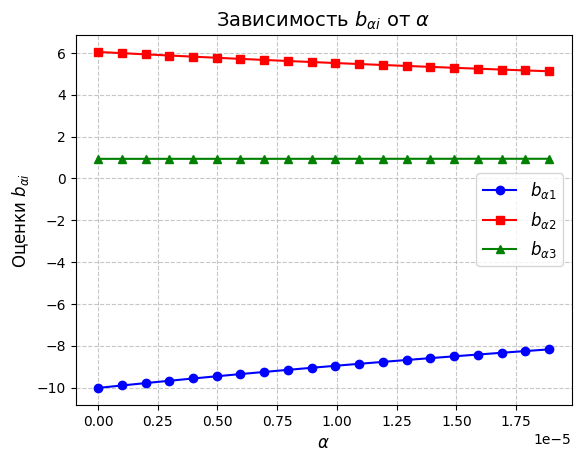

In [59]:
plt.plot(df.index, df['b1'], label='$b_{\\alpha 1}$', color='blue', marker='o')
plt.plot(df.index, df['b2'], label='$b_{\\alpha 2}$', color='red', marker='s')
plt.plot(df.index, df['b3'], label='$b_{\\alpha 3}$', color='green', marker='^')

# Настройки графика
plt.xlabel('$\\alpha$', fontsize=12)
plt.ylabel('Оценки $b_{\\alpha i}$', fontsize=12)
plt.title('Зависимость $b_{\\alpha i}$ от $\\alpha$', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

In [60]:
df['Q'] = (df - betta).pow(2).sum(axis=1)
df['lnQ'] = np.log(df['Q'])

In [61]:
df.T

alpha,0.000000e+00,9.936186e-07,1.987237e-06,2.980856e-06,3.974474e-06,4.968093e-06,5.961711e-06,6.955330e-06,7.948948e-06,8.942567e-06,9.936186e-06,1.092980e-05,1.192342e-05,1.291704e-05,1.391066e-05,1.490428e-05,1.589790e-05,1.689152e-05,1.788513e-05,1.887875e-05
b1,-10.015411,-9.898936,-9.785035,-9.673625,-9.564624,-9.457955,-9.353544,-9.251320,-9.151215,-9.053164,-8.957105,-8.862976,-8.770721,-8.680285,-8.591613,-8.504655,-8.419362,-8.335686,-8.253581,-8.173005
b2,6.048805,5.990302,5.933092,5.877133,5.822385,5.768807,5.716364,5.665019,5.614739,5.565490,5.517241,5.469963,5.423625,5.378201,5.333663,5.289986,5.247145,5.205117,5.163877,5.123406
b3,0.936712,0.936964,0.937211,0.937452,0.937688,0.937919,0.938146,0.938367,0.938584,0.938796,0.939004,0.939208,0.939408,0.939604,0.939796,0.939984,0.940169,0.940351,0.940528,0.940703
Q,80.643645,78.319674,76.079933,73.920594,71.838040,69.828851,67.889793,66.017805,64.209986,62.463590,60.776011,59.144779,57.567548,56.042093,54.566297,53.138149,51.755739,50.417245,49.120938,47.865169
lnQ,4.390040,4.360799,4.331785,4.302991,4.274414,4.246047,4.217886,4.189924,4.162159,4.134584,4.107195,4.079988,4.052959,4.026103,3.999416,3.972895,3.946535,3.920333,3.894285,3.868388


In [62]:
def MVQE(Q):
    # Min Value Quadra Error 
    return max(Q) / min(Q)

In [63]:
min(df['Q'])

47.86516860970639

In [64]:
print(MVQE(df['Q']))

1.684808536478921


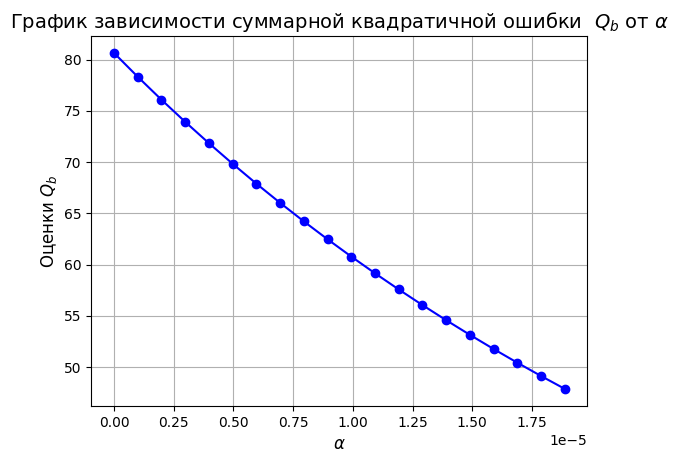

In [80]:
plt.plot(df.index, df['Q'], label='$b_{\\alpha 1}$', color='blue', marker='o')
plt.title('График зависимости суммарной квадратичной ошибки  $Q_b$ от $\\alpha$', fontsize=14)
plt.xlabel('$\\alpha$', fontsize=12)
plt.ylabel('Оценки $Q_b$', fontsize=12)
plt.grid()


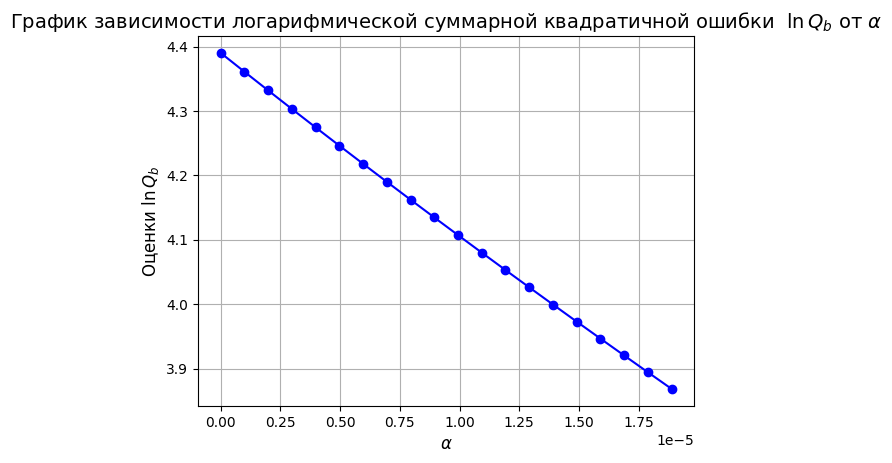

In [79]:
plt.plot(df.index, df['lnQ'], label='$b_{\\alpha 1}$', color='blue', marker='o')
plt.title('График зависимости логарифмической суммарной квадратичной ошибки  $\\ln Q_b$ от $\\alpha$', fontsize=14)
plt.xlabel('$\\alpha$', fontsize=12)
plt.ylabel('Оценки $\\ln{Q_b}$', fontsize=12)
plt.grid()

In [99]:
df.iloc[-1, :][:3] / b

b1    0.816043
b2    0.847011
b3    1.004261
Name: 1.8878752600169692e-05, dtype: float64

In [100]:
df.iloc[-1, :][:3]

b1   -8.173005
b2    5.123406
b3    0.940703
Name: 1.8878752600169692e-05, dtype: float64